#### Integration of Haber 2017 and Grün 2016 stem cells with `scVI` and `scANVI` pipeline
- **Developed by:** Anna Maguza
- **Affilation:** Faculty of Medicine, Würzburg University
- **Date of creation:** 15th November 2024
- **Last modified date:** 15th November 2024

This notebook is created to integrate mouse intestinal stem cells from Grün, 2016 dataset and all cells from Haber, 2017 study using `scVI` and `scANVI` tools. Then we measure the quality of integration with `scIB` metrics.

Additionally, we extract differentially expressed genes Grün,2016 Lgr5+ cells vs Haber, 2017 Lgr5- cells using `scANVI` model bayes factors. 

### Import packages

In [1]:
import scvi
import torch
import anndata
import warnings
import numpy as np
import scanpy as sc
import pandas as pd
import plotnine as p
from pywaffle import Waffle
import matplotlib.pyplot as plt
from scib_metrics.benchmark import Benchmarker
from datetime import datetime
import json
import anndata as ad

2024-11-15 14:48:03.749044: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-15 14:48:03.749087: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-15 14:48:03.749117: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-15 14:48:04.382494: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


##### Setup working environment

In [2]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi = 180, color_map = 'magma_r', dpi_save = 300, vector_friendly = True, format = 'svg')

In [3]:
warnings.simplefilter(action = 'ignore')
scvi.settings.seed = 1712
%config InlineBackend.print_figure_kwargs = {'facecolor' : "w"}
%config InlineBackend.figure_format = 'retina'
torch.set_float32_matmul_precision('medium')

Seed set to 1712


In [4]:
arches_params = dict(
    use_layer_norm = "both",
    use_batch_norm = "none",
    encode_covariates = True,
    dropout_rate = 0.2,
    n_layers = 3,
)

In [5]:
def X_is_raw(adata):
    return np.array_equal(adata.X.sum(axis=0).astype(int), adata.X.sum(axis=0))

#### Read in data

In [6]:
grun = sc.read_h5ad("data/Grun_2016/gut_mm_Grün2016_LGR5_SC_QC_AM_13112024_142926_raw.h5ad")
grun

AnnData object with n_obs × n_vars = 581 × 15890
    obs: 'sample', 'Instrument', 'Sample Name', 'source_name', 'SRA Study', 'strain', 'tissue', 'cell_type', 'cell_id', 'n_genes', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'ensemble_gene_id', 'n_cells', 'ensembl_gene_id', 'start_position', 'end_position', 'chromosome_name', 'gene_name', 'mito', 'ribo', 'hb', 'n_counts', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'Sample Name_colors', 'processing_history'

In [7]:
X_is_raw(grun)

True

In [8]:
haber = sc.read_h5ad("data/Haber_2017_Smartseq/gut_mm_Haber2017_SmartSeq2_QCfiltered_AM_15112024_113549_raw.h5ad")
haber

AnnData object with n_obs × n_vars = 1453 × 51241
    obs: 'barcode', 'Gene_marker', 'Donor_ID', 'GFP_intensity', 'Cell_Type', 'cell_type_extended', 'n_genes', 'n_counts', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'ensemble_gene_id_version', 'ensemble_gene_id', 'start_position', 'end_position', 'chromosome_name', 'external_gene_name', 'n_counts', 'n_cells', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'Cell_Type_colors', 'processing_history'

In [9]:
X_is_raw(haber)

True

#### Prepare obs

In [10]:
haber.obs['Study_name'] = 'Haber et al. 2017'
grun.obs['Study_name'] = 'Grun et al. 2016'
haber.obs['Library_preparation_protocol'] = 'Smart-seq2'
grun.obs['Library_preparation_protocol'] = 'CEL-seq'

In [11]:
grun.obs['Sample_ID'] = grun.obs['Sample Name'].copy()

In [12]:
haber.obs['Sample_ID'] = haber.obs['Donor_ID'].copy()

In [13]:
haber.obs['cell_type'] = haber.obs['Cell_Type'].copy()

#### Prepare var

In [14]:
common_genes = set(grun.var['ensembl_gene_id']).intersection(set(haber.var['ensemble_gene_id']))
print(f"Number of common genes: {len(common_genes)}")

Number of common genes: 15402


In [15]:
grun = grun[:, grun.var['ensembl_gene_id'].isin(common_genes)]
haber = haber[:, haber.var['ensemble_gene_id'].isin(common_genes)]

print(f"Grun dataset shape after filtering: {grun.shape}")
print(f"Haber dataset shape after filtering: {haber.shape}")

Grun dataset shape after filtering: (581, 15402)
Haber dataset shape after filtering: (1453, 15402)


In [16]:
grun.var.index = grun.var['ensembl_gene_id'].copy()
haber.var.index = haber.var['ensemble_gene_id'].copy()

In [17]:
adata_raw = haber.concatenate(grun, batch_key = 'dataset', batch_categories = ['haber', 'grun'], join='inner', index_unique = None)

#### Extract highly variable genes

In [18]:
haber.layers['counts'] = haber.X.copy()

In [19]:
sc.pp.highly_variable_genes(haber, 
                          flavor='seurat_v3',
                          n_top_genes=7000,
                          batch_key='Sample_ID', 
                          subset=True,
                          layer = "counts",
                          span=1)

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


#### Concatinate datasets

In [20]:
adata = haber.concatenate(grun, batch_key = 'dataset', batch_categories = ['haber', 'grun'], join='inner', index_unique = None)

#### Visualize uncorrected dataset

In [21]:
sc.pp.pca(adata)

computing PCA
    with n_comps=50
    finished (0:00:00)


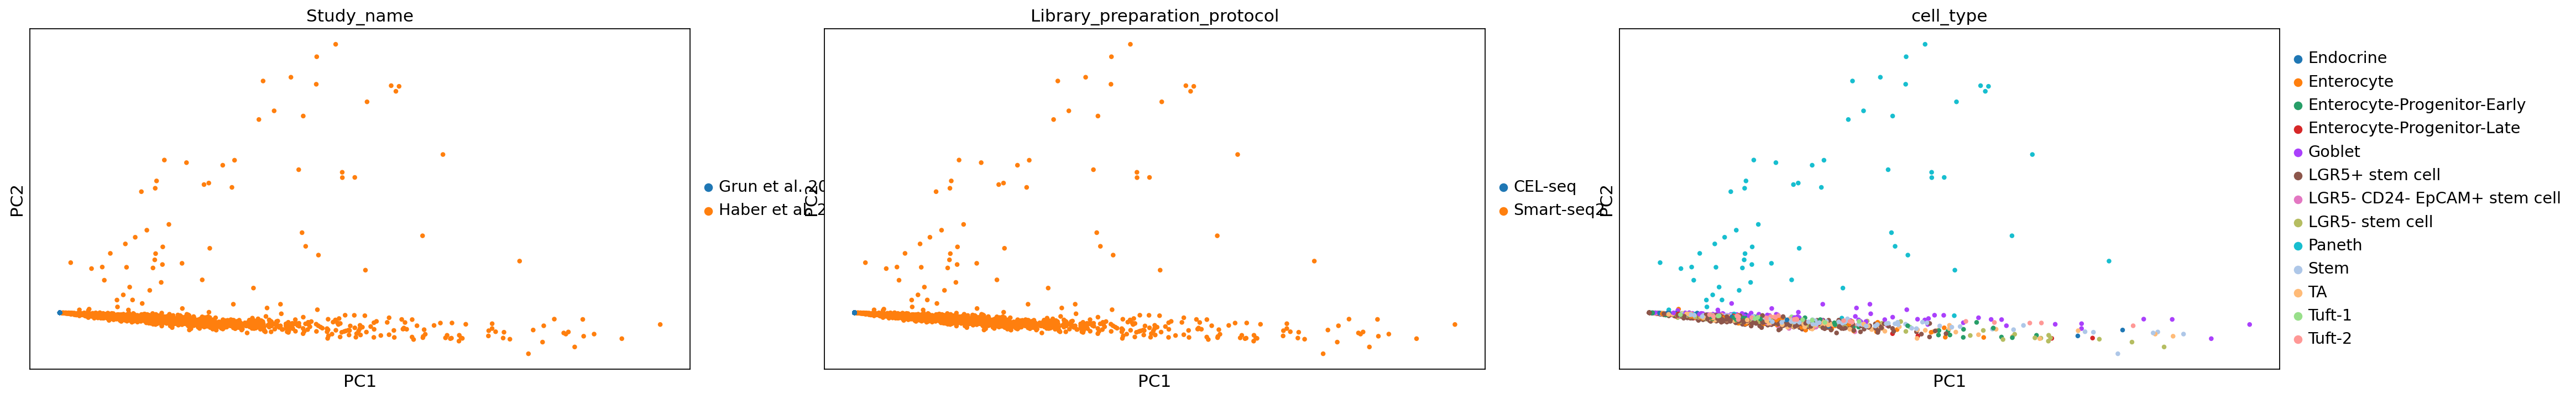

In [22]:
sc.set_figure_params(figsize=(10,5))
sc.pl.pca(adata,color=["Study_name", "Library_preparation_protocol", "cell_type"])

#### Run scVI

In [23]:
adata.layers['counts'] = adata.X.copy()

In [24]:
scvi.model.SCVI.setup_anndata(adata,
                              categorical_covariate_keys=['Study_name'],
                              #continuous_covariate_keys=['n_genes', 'n_counts'],
                              labels_key = "cell_type", 
                              layer = 'counts')

In [25]:
scvi_model = scvi.model.SCVI(adata,
                            n_latent = 50, 
                            n_layers = 3, 
                            #n_latent=8,          
                            #n_layers=1,          
                            #n_hidden=32, 
                            dispersion = 'gene-batch', 
                            #dropout_rate=0.2,
                            gene_likelihood = 'nb')

In [26]:
scvi_model.train(
    max_epochs=700,
    early_stopping=True,
    early_stopping_patience=30,
    train_size=0.9,
    validation_size=0.1,
    check_val_every_n_epoch = 1, 
    enable_progress_bar = True, 
    accelerator = "gpu",
    devices = [1]
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Training:   0%|          | 0/700 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 30 records. Best score: 12069.719. Signaling Trainer to stop.


In [27]:
adata.obsm["X_scVI"] = scvi_model.get_latent_representation(adata)

#### Evaluate model performance using the [_Svensson_](https://www.nxn.se/valent/2023/8/10/training-scvi-posterior-predictive-distributions-over-epochs) method

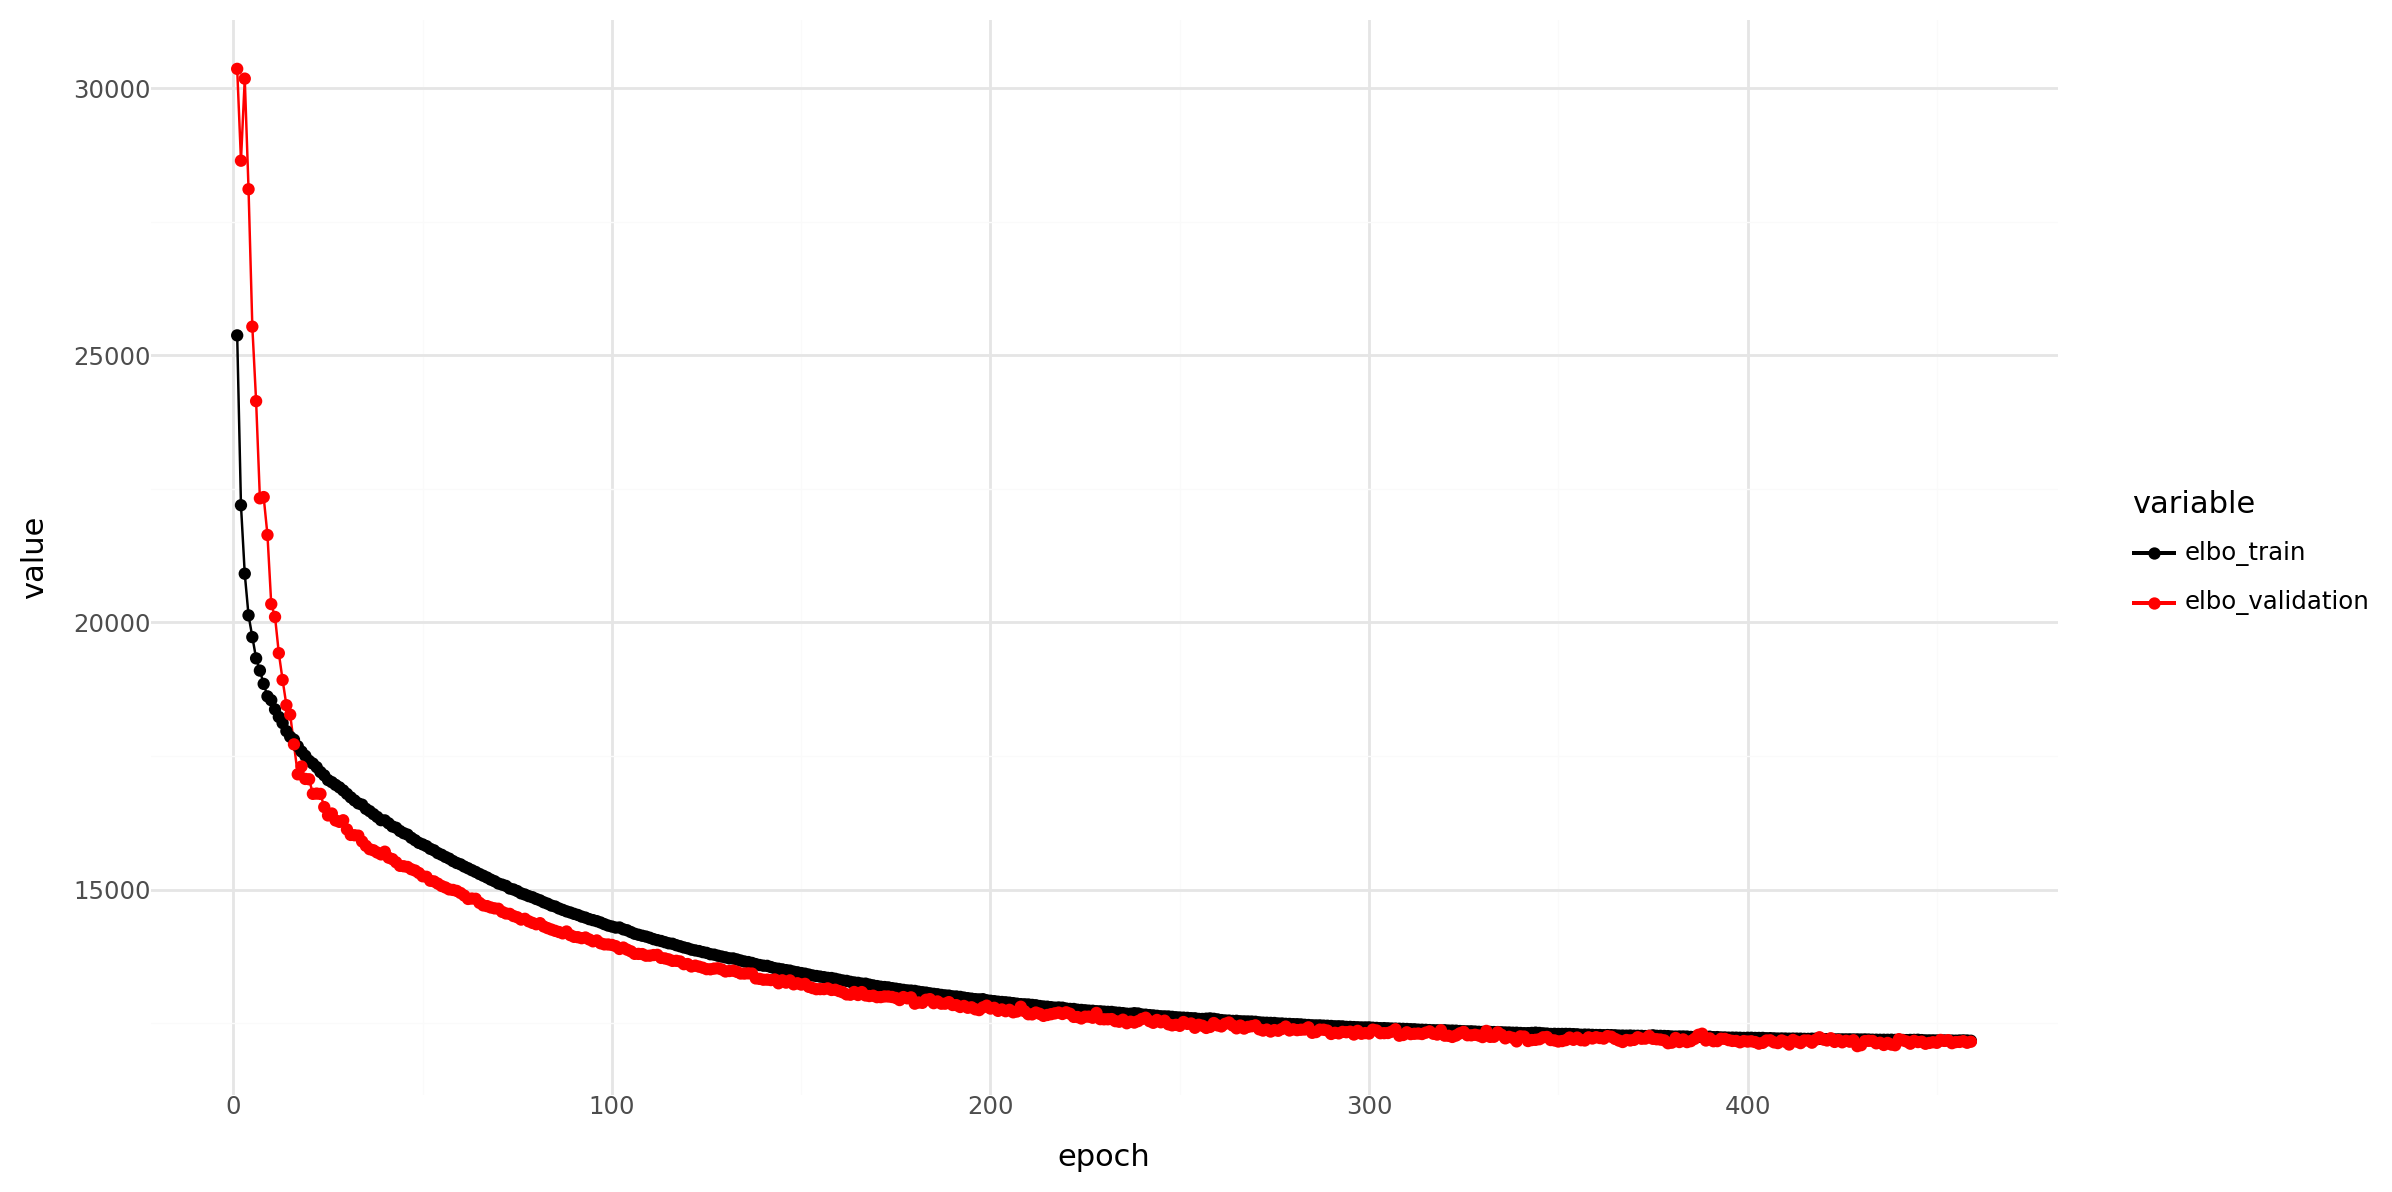

In [28]:
history_df = (
    scvi_model.history['elbo_train'].astype(float)
    .join(scvi_model.history['elbo_validation'].astype(float))
    .reset_index()
    .melt(id_vars = ['epoch'])
)

p.options.figure_size = 12, 6

p_ = (
    p.ggplot(p.aes(x = 'epoch', y = 'value', color = 'variable'), history_df.query('epoch > 0'))
    + p.geom_line()
    + p.geom_point()
    + p.scale_color_manual({'elbo_train': 'black', 'elbo_validation': 'red'})
    + p.theme_minimal()
)

p_.draw()

#### Label transfer with `scANVI` 

In [29]:
scanvi_model = scvi.model.SCANVI.from_scvi_model(scvi_model, 'Unknown')

In [30]:
scanvi_model.train(
    max_epochs=320,
    early_stopping=True,
    check_val_every_n_epoch=1,
    enable_progress_bar=True,
    accelerator="gpu",
    devices=[1]
)

INFO     Training for 320 epochs.                                                                                  


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Training:   0%|          | 0/320 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 45 records. Best score: 12067.376. Signaling Trainer to stop.


- Extract latent representation

In [31]:
adata.obsm["X_scANVI"] = scanvi_model.get_latent_representation(adata)

### Explore model performance using the [_Svensson_](https://www.nxn.se/valent/2023/8/10/training-scvi-posterior-predictive-distributions-over-epochs) method

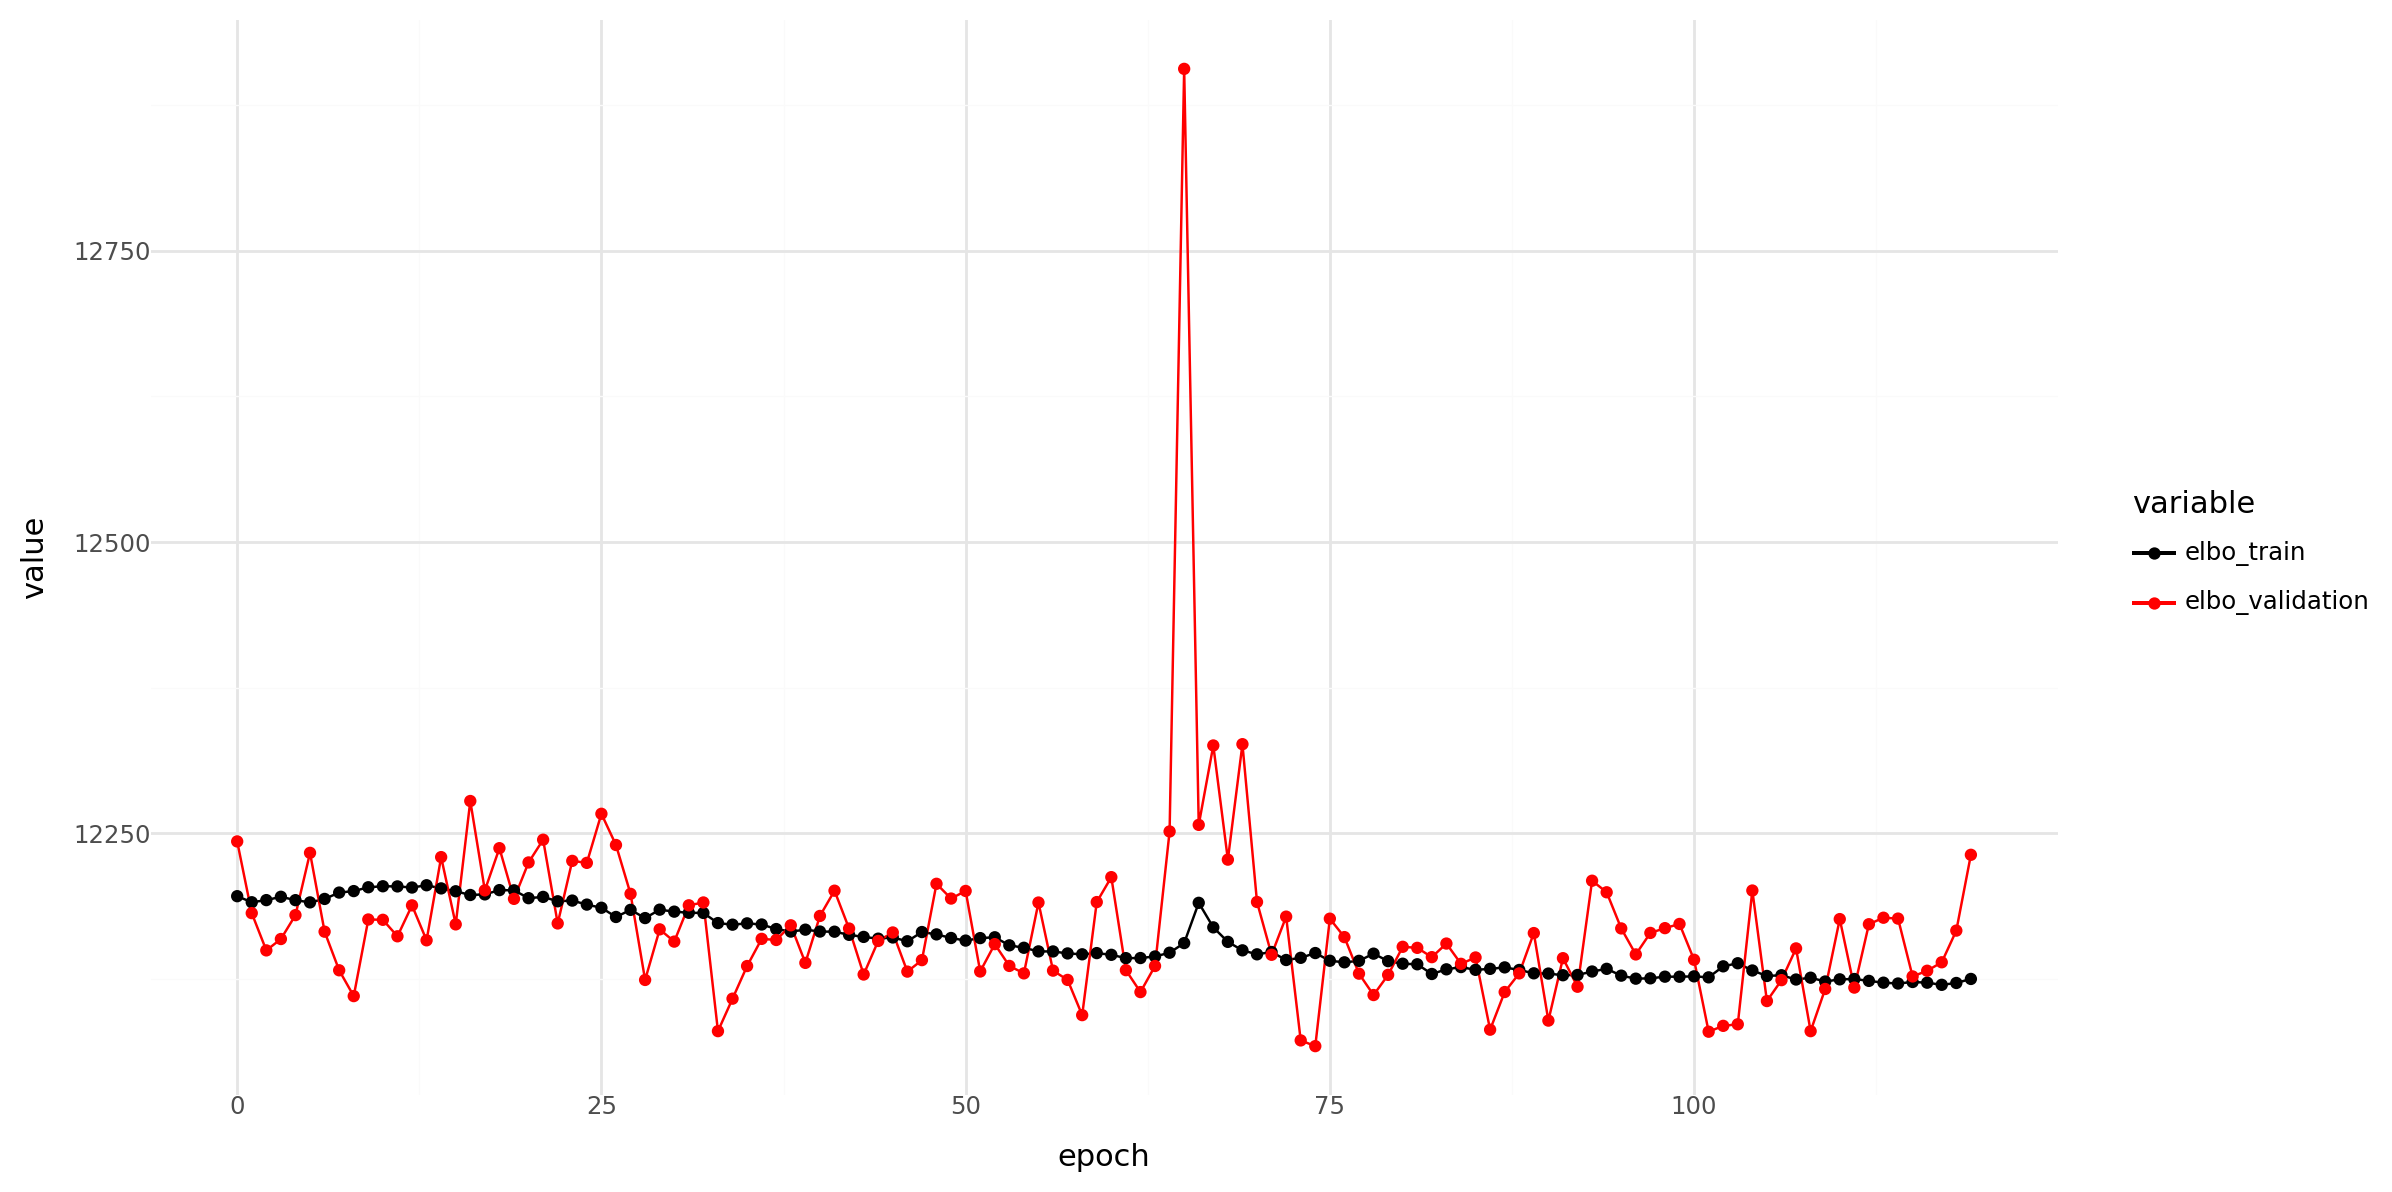

In [32]:
history_df = (
    scanvi_model.history['elbo_train'].astype(float)
    .join(scanvi_model.history['elbo_validation'].astype(float))
    .reset_index()
    .melt(id_vars = ['epoch'])
)

p.options.figure_size = 12, 6

p_ = (
    p.ggplot(p.aes(x = 'epoch', y = 'value', color = 'variable'), history_df.query('epoch < 340'))
    + p.geom_line()
    + p.geom_point()
    + p.scale_color_manual({'elbo_train': 'black', 'elbo_validation': 'red'})
    + p.theme_minimal()
)

p_.draw()

+ Visualize dataset

In [33]:
sc.pp.neighbors(adata, use_rep = "X_scANVI", n_neighbors = 50, metric = 'minkowski')
sc.tl.umap(adata, min_dist = 0.2, spread = 2, random_state = 1712)

computing neighbors


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:02)


In [34]:
sc.set_figure_params(dpi = 300, figsize=(5,5))
sc.pl.umap(adata, color = ["Study_name", "Library_preparation_protocol", "cell_type", 'n_genes', 'n_counts','Sample_ID'], ncols = 3, frameon = False, size = 7)

#### Check scIB metrics

In [35]:
bm = Benchmarker(
    adata,
    batch_key='Study_name',
    label_key='cell_type',
    embedding_obsm_keys=['X_pca', 'X_scVI', 'X_scANVI'],
    n_jobs=-1
)

bm.benchmark()

computing PCA
    with n_comps=50
    finished (0:00:01)


Embeddings:   0%|                                                                                               | 0/3 [00:00<?, ?it/s]WARNING:jax._src.xla_bridge:An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


INFO     Endocrine consists of a single batch or is too small. Skip.                                               
INFO     Enterocyte consists of a single batch or is too small. Skip.                                              
INFO     Enterocyte-Progenitor-Early consists of a single batch or is too small. Skip.                             
INFO     Enterocyte-Progenitor-Late consists of a single batch or is too small. Skip.                              
INFO     Goblet consists of a single batch or is too small. Skip.                                                  
INFO     LGR5- CD24- EpCAM+ stem cell consists of a single batch or is too small. Skip.                            
INFO     LGR5- stem cell consists of a single batch or is too small. Skip.                                         
INFO     Paneth consists of a single batch or is too small. Skip.                                                  
INFO     Stem consists of a single batch or is too small. Skip.         

Embeddings:  33%|█████████████████████████████                                                          | 1/3 [00:05<00:10,  5.10s/it]

INFO     Endocrine consists of a single batch or is too small. Skip.                                               
INFO     Enterocyte consists of a single batch or is too small. Skip.                                              
INFO     Enterocyte-Progenitor-Early consists of a single batch or is too small. Skip.                             
INFO     Enterocyte-Progenitor-Late consists of a single batch or is too small. Skip.                              
INFO     Goblet consists of a single batch or is too small. Skip.                                                  
INFO     LGR5- CD24- EpCAM+ stem cell consists of a single batch or is too small. Skip.                            
INFO     LGR5- stem cell consists of a single batch or is too small. Skip.                                         
INFO     Paneth consists of a single batch or is too small. Skip.                                                  
INFO     Stem consists of a single batch or is too small. Skip.         

Embeddings:  67%|██████████████████████████████████████████████████████████                             | 2/3 [00:07<00:03,  3.44s/it]

INFO     Endocrine consists of a single batch or is too small. Skip.                                               
INFO     Enterocyte consists of a single batch or is too small. Skip.                                              
INFO     Enterocyte-Progenitor-Early consists of a single batch or is too small. Skip.                             
INFO     Enterocyte-Progenitor-Late consists of a single batch or is too small. Skip.                              
INFO     Goblet consists of a single batch or is too small. Skip.                                                  
INFO     LGR5- CD24- EpCAM+ stem cell consists of a single batch or is too small. Skip.                            
INFO     LGR5- stem cell consists of a single batch or is too small. Skip.                                         
INFO     Paneth consists of a single batch or is too small. Skip.                                                  
INFO     Stem consists of a single batch or is too small. Skip.         

Embeddings: 100%|███████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:09<00:00,  3.23s/it]


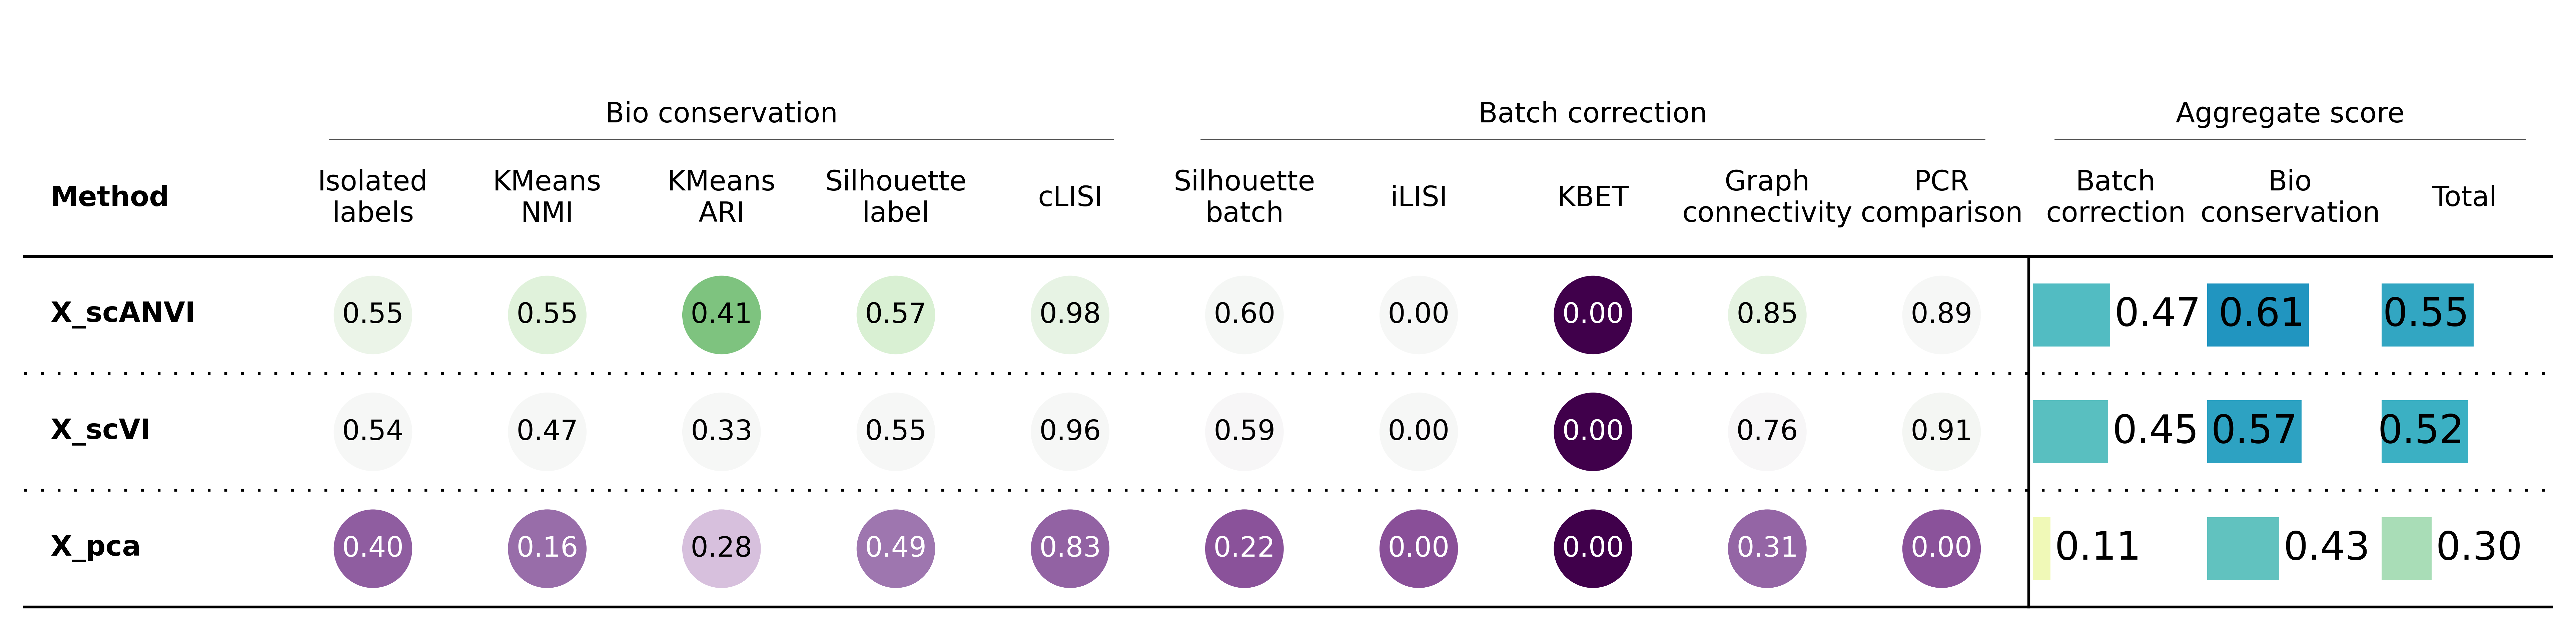

In [36]:
bm.plot_results_table(min_max_scale=False)

#### Extract DEGs using models bayes factors

In [37]:
adata.obs['cell_type'] = adata.obs['cell_type'].astype('str')
adata.obs['Study_name'] = adata.obs['Study_name'].astype('str')

In [38]:
adata.obs['cell_type_and_study'] = adata.obs['cell_type'] + '_' + adata.obs['Study_name']

In [39]:
adata.obs['cell_type_and_study'].value_counts()

cell_type_and_study
LGR5+ stem cell_Grun et al. 2016                  581
LGR5+ stem cell_Haber et al. 2017                 351
TA_Haber et al. 2017                              190
Enterocyte_Haber et al. 2017                      149
Stem_Haber et al. 2017                            141
Goblet_Haber et al. 2017                          118
Enterocyte-Progenitor-Early_Haber et al. 2017     112
Paneth_Haber et al. 2017                           69
Enterocyte-Progenitor-Late_Haber et al. 2017       68
LGR5- stem cell_Haber et al. 2017                  66
LGR5- CD24- EpCAM+ stem cell_Haber et al. 2017     51
Tuft-1_Haber et al. 2017                           50
Tuft-2_Haber et al. 2017                           49
Endocrine_Haber et al. 2017                        39
Name: count, dtype: int64

In [40]:
adata.obs['cell_type_and_study'] = adata.obs['cell_type_and_study'].replace(
    'LGR5- CD24- EpCAM+ stem cell_Haber et al. 2017', 
    'LGR5- stem cell_Haber et al. 2017'
)

* Grun et al. 2016 LGR5+ stem cells vs Haber et al. 2017 LGR5- stem cells

In [41]:
de_df = scanvi_model.differential_expression(
    adata,
    groupby='cell_type_and_study',  
    group1='LGR5+ stem cell_Grun et al. 2016', 
    group2='LGR5- stem cell_Haber et al. 2017',
    batch_correction=True,
    all_stats=True
)

DE...:   0%|          | 0/1 [00:00<?, ?it/s]

In [42]:
de_df = de_df.merge(grun.var['gene_name'], left_on=de_df.index, right_index=True)

In [43]:
de_df

,key_0,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,...,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,is_de_fdr_0.05,comparison,group1,group2,gene_name
ENSMUSG00000031885,ENSMUSG00000031885,1.0000,0.0000,18.420681,0.000167,1.998735e-05,0.0,0.25,3.369406,3.105874,...,19.632479,0.036145,0.401709,1.720034,0.217481,True,LGR5+ stem cell_Grun et al. 2016 vs LGR5- stem...,LGR5+ stem cell_Grun et al. 2016,LGR5- stem cell_Haber et al. 2017,Cbfb
ENSMUSG00000000303,ENSMUSG00000000303,1.0000,0.0000,18.420681,0.004833,1.256334e-03,0.0,0.25,2.042784,1.923926,...,1162.880342,0.638554,1.000000,51.986577,12.012977,True,LGR5+ stem cell_Grun et al. 2016 vs LGR5- stem...,LGR5+ stem cell_Grun et al. 2016,LGR5- stem cell_Haber et al. 2017,Cdh1
ENSMUSG00000031608,ENSMUSG00000031608,1.0000,0.0000,18.420681,0.000950,7.722446e-05,0.0,0.25,3.608917,3.429718,...,77.162393,0.182444,0.683761,9.635712,0.827841,True,LGR5+ stem cell_Grun et al. 2016 vs LGR5- stem...,LGR5+ stem cell_Grun et al. 2016,LGR5- stem cell_Haber et al. 2017,Galnt7
ENSMUSG00000051839,ENSMUSG00000051839,1.0000,0.0000,18.420681,0.000012,1.806356e-10,0.0,0.25,16.361038,16.066360,...,0.068376,0.001721,0.008547,0.163921,0.000581,True,LGR5+ stem cell_Grun et al. 2016 vs LGR5- stem...,LGR5+ stem cell_Grun et al. 2016,LGR5- stem cell_Haber et al. 2017,Gypa
ENSMUSG00000054034,ENSMUSG00000054034,1.0000,0.0000,18.420681,0.000010,1.315024e-10,0.0,0.25,20.690105,20.231730,...,0.000000,0.001721,0.000000,0.047678,0.000000,True,LGR5+ stem cell_Grun et al. 2016 vs LGR5- stem...,LGR5+ stem cell_Grun et al. 2016,LGR5- stem cell_Haber et al. 2017,Tceal5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000060036,ENSMUSG00000060036,0.5738,0.4262,0.297372,0.001572,1.575256e-03,0.0,0.25,0.017614,0.022557,...,1430.128205,0.308090,1.000000,18.596269,15.304852,False,LGR5+ stem cell_Grun et al. 2016 vs LGR5- stem...,LGR5+ stem cell_Grun et al. 2016,LGR5- stem cell_Haber et al. 2017,Rpl3
ENSMUSG00000048000,ENSMUSG00000048000,0.5698,0.4302,0.281035,0.000115,1.088450e-04,0.0,0.25,0.123676,0.076591,...,101.709402,0.032702,0.829060,1.008029,1.040289,False,LGR5+ stem cell_Grun et al. 2016 vs LGR5- stem...,LGR5+ stem cell_Grun et al. 2016,LGR5- stem cell_Haber et al. 2017,Gigyf2
ENSMUSG00000023175,ENSMUSG00000023175,0.5556,0.4444,0.223324,0.000989,9.488425e-04,0.0,0.25,0.097916,0.104975,...,936.367521,0.218589,1.000000,9.995940,9.522746,False,LGR5+ stem cell_Grun et al. 2016 vs LGR5- stem...,LGR5+ stem cell_Grun et al. 2016,LGR5- stem cell_Haber et al. 2017,Bsg
ENSMUSG00000000346,ENSMUSG00000000346,0.5490,0.4510,0.196631,0.000421,4.194832e-04,0.0,0.25,0.033841,0.001279,...,375.034188,0.084337,1.000000,4.028878,3.930231,False,LGR5+ stem cell_Grun et al. 2016 vs LGR5- stem...,LGR5+ stem cell_Grun et al. 2016,LGR5- stem cell_Haber et al. 2017,Dazap2


* Haber et al. 2017 LGR5+ stem cells vs Haber et al. 2017 LGR5- stem cells

In [44]:
de_df2 = scanvi_model.differential_expression(
    adata,
    groupby='cell_type_and_study',  
    group1='LGR5+ stem cell_Haber et al. 2017', 
    group2='LGR5- stem cell_Haber et al. 2017',
    batch_correction=True,
    all_stats=True
)

DE...:   0%|          | 0/1 [00:00<?, ?it/s]

In [45]:
de_df2 = de_df2.merge(grun.var['gene_name'], left_on=de_df2.index, right_index=True)

#### Extract DEGs using usual `scanpy` functions

In [46]:
adata_log = adata_raw.copy()
sc.pp.normalize_total(adata_log, target_sum = 1e4, exclude_highly_expressed = True) 
sc.pp.log1p(adata_log)

normalizing counts per cell. The following highly-expressed genes are not considered during normalization factor computation:
['ENSMUSG00000038209', 'ENSMUSG00000000394', 'ENSMUSG00000027350', 'ENSMUSG00000027876', 'ENSMUSG00000028255', 'ENSMUSG00000054932', 'ENSMUSG00000047730', 'ENSMUSG00000049350', 'ENSMUSG00000025515', 'ENSMUSG00000074444', 'ENSMUSG00000058618', 'ENSMUSG00000064213', 'ENSMUSG00000069515', 'ENSMUSG00000014351', 'ENSMUSG00000020581', 'ENSMUSG00000060615', 'ENSMUSG00000022026', 'ENSMUSG00000004366', 'ENSMUSG00000119584', 'ENSMUSG00000064339']
    finished (0:00:00)


In [47]:
adata_log.obs['cell_type'] = adata_log.obs['cell_type'].astype('str')
adata_log.obs['Study_name'] = adata_log.obs['Study_name'].astype('str')
adata_log.obs['cell_type_and_study'] = adata_log.obs['cell_type'] + '_' + adata_log.obs['Study_name']

In [48]:
adata_log.obs['cell_type_and_study'] = adata_log.obs['cell_type_and_study'].replace(
    'LGR5- CD24- EpCAM+ stem cell_Haber et al. 2017', 
    'LGR5- stem cell_Haber et al. 2017'
)

In [49]:
adata_log.obs['cell_type_and_study'].value_counts()

cell_type_and_study
LGR5+ stem cell_Grun et al. 2016                 581
LGR5+ stem cell_Haber et al. 2017                351
TA_Haber et al. 2017                             190
Enterocyte_Haber et al. 2017                     149
Stem_Haber et al. 2017                           141
Goblet_Haber et al. 2017                         118
LGR5- stem cell_Haber et al. 2017                117
Enterocyte-Progenitor-Early_Haber et al. 2017    112
Paneth_Haber et al. 2017                          69
Enterocyte-Progenitor-Late_Haber et al. 2017      68
Tuft-1_Haber et al. 2017                          50
Tuft-2_Haber et al. 2017                          49
Endocrine_Haber et al. 2017                       39
Name: count, dtype: int64

+ Grün 2016 Lgr5+ vs Haber 2017 Lgr5-

In [50]:
adata_filtered = adata_log[adata_log.obs['cell_type_and_study'].isin(['LGR5+ stem cell_Grun et al. 2016', 'LGR5- stem cell_Haber et al. 2017'])]

In [53]:
adata_filtered.obs['cell_type_and_study'].value_counts()

cell_type_and_study
LGR5+ stem cell_Grun et al. 2016     581
LGR5- stem cell_Haber et al. 2017    117
Name: count, dtype: int64

In [51]:
sc.tl.rank_genes_groups(adata_filtered, groupby="cell_type_and_study", method='wilcoxon', n_genes=150)
deg_wilcoxon_grun_haber = sc.get.rank_genes_groups_df(adata_filtered, group=None)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


In [52]:
sc.tl.rank_genes_groups(adata_filtered, groupby="cell_type_and_study", method='logreg', n_genes=150)
deg_log_reg_grun_haber = sc.get.rank_genes_groups_df(adata_filtered, group=None)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
 (0:00:00)


+ Haber 2017 Lgr5+ vs Haber 2017 Lgr5-

In [54]:
adata_filtered = adata_log[adata_log.obs['cell_type_and_study'].isin(['LGR5+ stem cell_Haber et al. 2017', 'LGR5- stem cell_Haber et al. 2017'])]

In [55]:
adata_filtered.obs['cell_type_and_study'].value_counts()

cell_type_and_study
LGR5+ stem cell_Haber et al. 2017    351
LGR5- stem cell_Haber et al. 2017    117
Name: count, dtype: int64

In [56]:
sc.tl.rank_genes_groups(adata_filtered, groupby="cell_type_and_study", method='wilcoxon', n_genes=150)
deg_wilcoxon_haber = sc.get.rank_genes_groups_df(adata_filtered, group=None)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


In [57]:
sc.tl.rank_genes_groups(adata_filtered, groupby="cell_type_and_study", method='logreg', n_genes=150)
deg_log_reg_haber = sc.get.rank_genes_groups_df(adata_filtered, group=None)

ranking genes


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
 (0:00:01)


#### Export data

In [59]:
adata_export = ad.AnnData(X=adata_raw.X, obs=adata.obs, var=adata_raw.var,
                          uns=adata.uns, obsm=adata.obsm, obsp=adata.obsp)

In [60]:
project = 'gut'
species = 'mm'
atribute = 'Grün2016_Haber2017_allcells_integrated'
name = 'AM'
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')
counts = 'raw'

adata_export.uns['processing_history'] = []
adata_export.uns['processing_history']={
    'timestamp': timestamp,
    'step': 'integrated all cells from Grün2016 and Haber201 with scVI-scANVI',}

adata_export.write_h5ad(f"data/Haber_2017_Smartseq/{project}_{species}_{atribute}_{name}_{timestamp}_{counts}.h5ad")

In [61]:
atribute = 'Grün2016_Haber2017_allcellsintegrated'
counts = 'HGVraw'

adata.uns['processing_history'] = []
adata.uns['processing_history']={
    'timestamp': timestamp,
    'step': 'integrated all cells from Grün2016 and Haber201 with scVI-scANVI',}

adata.write_h5ad(f"data/Haber_2017_Smartseq/{project}_{species}_{atribute}_{name}_{timestamp}_{counts}.h5ad")

In [62]:
atribute = 'Grün2016_LGR5+_vs_Haber2017_LGR5-_bayes'
de_df.to_csv(f"data/Haber_2017_Smartseq/{project}_{species}_{atribute}_{name}_{timestamp}_DEGs.csv")

In [63]:
atribute = 'DEG_Haber2017_LGR5+_vs_Haber2017_LGR5-_bayes'
de_df.to_csv(f"data/Haber_2017_Smartseq/{project}_{species}_{atribute}_{name}_{timestamp}_DEGs.csv")

In [64]:
atribute = 'Grün2016_Haber2017_allcells_integrated'
scanvi_model.save(f"data/Haber_2017_Smartseq/{project}_{species}_{atribute}_{name}_{timestamp}_scanvi_model", overwrite=True)

In [65]:
atribute = 'DEG_Haber2017_LGR5+_vs_Haber2017_LGR5-_wilcoxon'
deg_wilcoxon_haber.to_csv(f"data/Haber_2017_Smartseq/{project}_{species}_{atribute}_{name}_{timestamp}_DEGs.csv")

In [66]:
atribute = 'DEG_Haber2017_LGR5+_vs_Haber2017_LGR5-_logreg'
deg_log_reg_haber.to_csv(f"data/Haber_2017_Smartseq/{project}_{species}_{atribute}_{name}_{timestamp}_DEGs.csv")

In [67]:
atribute = 'DEG_Grün2016_LGR5+_vs_Haber2017_LGR5-_wilcoxon'
deg_wilcoxon_grun_haber.to_csv(f"data/Haber_2017_Smartseq/{project}_{species}_{atribute}_{name}_{timestamp}_DEGs.csv")

In [68]:
atribute = 'DEG_Grün2016_LGR5+_vs_Haber2017_LGR5-_logreg'
deg_log_reg_grun_haber.to_csv(f"data/Haber_2017_Smartseq/{project}_{species}_{atribute}_{name}_{timestamp}_DEGs.csv")